# Case Study: Self-Pruning Neural Network (CIFAR-10)

This notebook implements the complete assignment:
- Custom `PrunableLinear` layer with learnable gate scores.
- Loss with sparsity regularization: `TotalLoss = CE + lambda * L1(gates)`.
- Training and comparison across multiple `lambda` values.
- EDA and visualizations.
- Detailed evaluation (accuracy, precision/recall/F1, confusion matrix, sparsity).
- Model outcomes (sample predictions).

> Quick-run defaults are enabled (`EPOCHS=2`) so you can see outputs fast. Increase epochs later for stronger results.

In [7]:
# If needed in Colab, uncomment:
# !pip install -q torch torchvision seaborn scikit-learn tqdm

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [8]:
# -----------------------------
# Config (quick output first)
# -----------------------------
SEED = 42
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 2               # quick run (increase later, e.g., 10-25)
LAMBDA_VALUES = [1e-5, 1e-4, 5e-4]  # low, medium, high sparsity pressure
SPARSITY_THRESHOLD = 1e-2

# Set True for quick run; set False for full CIFAR-10 train/test
QUICK_MODE = True
QUICK_TRAIN_SAMPLES = 15000
QUICK_TEST_SAMPLES = 3000

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [9]:
# -----------------------------
# Runtime dataset download
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])


def load_cifar10_with_ssl_fallback(root='./data'):
    os.makedirs(root, exist_ok=True)
    try:
        tr = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
        te = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform)
        return tr, te
    except Exception as e:
        print('torchvision download failed. Trying manual SSL fallback:', e)
        import ssl
        import tarfile
        import urllib.request

        url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
        archive_path = os.path.join(root, 'cifar-10-python.tar.gz')
        extract_dir = os.path.join(root, 'cifar-10-batches-py')

        if not os.path.exists(extract_dir):
            ctx = ssl._create_unverified_context()
            with urllib.request.urlopen(url, context=ctx) as response, open(archive_path, 'wb') as f:
                f.write(response.read())
            with tarfile.open(archive_path, 'r:gz') as tar:
                tar.extractall(path=root)

        tr = torchvision.datasets.CIFAR10(root=root, train=True, download=False, transform=transform)
        te = torchvision.datasets.CIFAR10(root=root, train=False, download=False, transform=transform)
        return tr, te


train_set_full, test_set_full = load_cifar10_with_ssl_fallback(root='./data')
class_names = train_set_full.classes

if QUICK_MODE:
    train_idx = np.random.choice(len(train_set_full), QUICK_TRAIN_SAMPLES, replace=False)
    test_idx = np.random.choice(len(test_set_full), QUICK_TEST_SAMPLES, replace=False)
    train_set = Subset(train_set_full, train_idx)
    test_set = Subset(test_set_full, test_idx)
else:
    train_set = train_set_full
    test_set = test_set_full

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Train size:', len(train_set), '| Test size:', len(test_set))
print('Classes:', class_names)

torchvision download failed. Trying manual SSL fallback: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>


/Users/diptman/Documents/sayantan/case_study/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train size: 15000 | Test size: 3000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/var/folders/kn/z6v754z50ddbph5g1x5ky8n00000gn/T/ipykernel_14063/1255099569.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_df, x='class', y='count', palette='viridis')


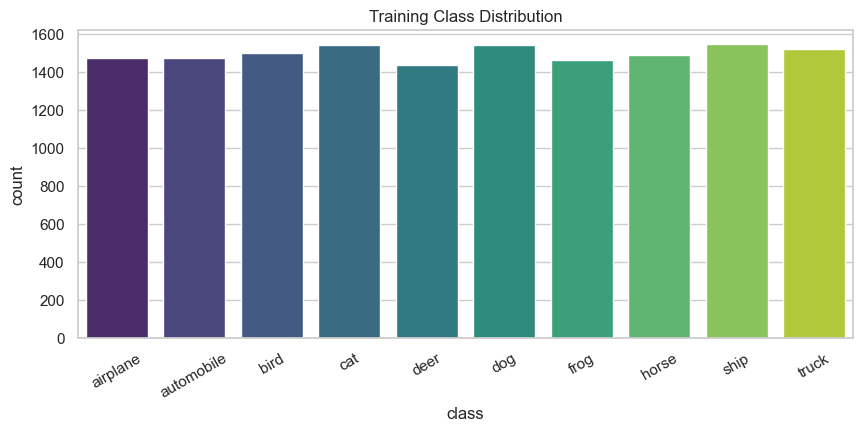

/Users/diptman/Documents/sayantan/case_study/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


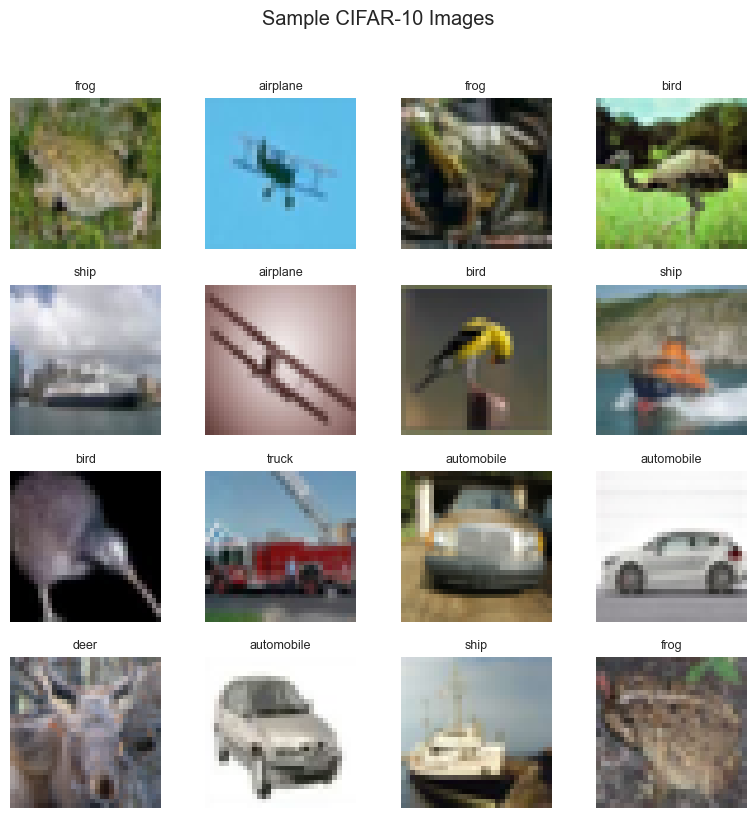

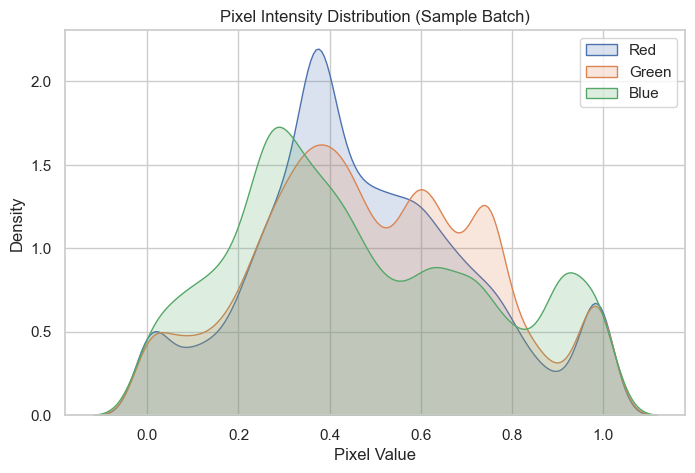

In [10]:
# -----------------------------
# EDA
# -----------------------------
def unnormalize(x):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

def get_targets(ds):
    if isinstance(ds, Subset):
        return [ds.dataset.targets[i] for i in ds.indices]
    return ds.targets

targets = get_targets(train_set)
class_counts = pd.Series(targets).value_counts().sort_index()
class_df = pd.DataFrame({'class': [class_names[i] for i in class_counts.index], 'count': class_counts.values})

plt.figure(figsize=(10, 4))
sns.barplot(data=class_df, x='class', y='count', palette='viridis')
plt.title('Training Class Distribution')
plt.xticks(rotation=30)
plt.show()

sample_images, sample_labels = next(iter(train_loader))
sample_images_unnorm = unnormalize(sample_images[:16].cpu())

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = sample_images_unnorm[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[sample_labels[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', y=1.02)
plt.tight_layout()
plt.show()

flat_pixels = sample_images_unnorm.reshape(sample_images_unnorm.size(0), 3, -1).numpy()
for ch, name in enumerate(['Red', 'Green', 'Blue']):
    sns.kdeplot(flat_pixels[:, ch, :].ravel(), label=name, fill=True, alpha=0.2)
plt.title('Pixel Intensity Distribution (Sample Batch)')
plt.xlabel('Pixel Value')
plt.legend()
plt.show()

In [11]:
# -----------------------------
# Prunable layer and model
# -----------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return nn.functional.linear(x, pruned_weights, self.bias)

    def gate_values(self):
        return torch.sigmoid(self.gate_scores)

class SelfPruningMLP(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dims=[512, 256], num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(input_dim, hidden_dims[0])
        self.fc2 = PrunableLinear(hidden_dims[0], hidden_dims[1])
        self.fc3 = PrunableLinear(hidden_dims[1], num_classes)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.drop(self.act(self.fc1(x)))
        x = self.drop(self.act(self.fc2(x)))
        x = self.fc3(x)
        return x

    def all_gate_values(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.gate_values().view(-1))
        return torch.cat(gates)

def sparsity_loss(model):
    return model.all_gate_values().sum()

def sparsity_level(model, threshold=1e-2):
    g = model.all_gate_values().detach().cpu().numpy()
    return (g < threshold).mean() * 100.0

In [12]:
# -----------------------------
# Train + evaluate utilities
# -----------------------------
def evaluate_model(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, report, cm, np.array(y_true), np.array(y_pred)

def train_one_lambda(lambda_val, epochs=2):
    model = SelfPruningMLP().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {'epoch': [], 'ce_loss': [], 'sp_loss': [], 'total_loss': [], 'train_acc': [], 'sparsity_%': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_ce, running_sp, running_total = 0.0, 0.0, 0.0
        correct, total = 0, 0

        pbar = tqdm(train_loader, desc=f'lambda={lambda_val} | epoch {epoch}/{epochs}', leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()

            logits = model(xb)
            ce = criterion(logits, yb)
            sp = sparsity_loss(model)
            loss = ce + lambda_val * sp

            loss.backward()
            optimizer.step()

            running_ce += ce.item() * xb.size(0)
            running_sp += sp.item() * xb.size(0)
            running_total += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_ce = running_ce / total
        train_sp = running_sp / total
        train_total = running_total / total
        train_acc = correct / total
        sp_level = sparsity_level(model, SPARSITY_THRESHOLD)

        history['epoch'].append(epoch)
        history['ce_loss'].append(train_ce)
        history['sp_loss'].append(train_sp)
        history['total_loss'].append(train_total)
        history['train_acc'].append(train_acc)
        history['sparsity_%'].append(sp_level)

        print(f"Epoch {epoch:02d} | CE: {train_ce:.4f} | SparsityLoss: {train_sp:.2f} | Total: {train_total:.4f} | TrainAcc: {train_acc:.4f} | Sparsity%: {sp_level:.2f}")

    test_acc, report, cm, y_true, y_pred = evaluate_model(model, test_loader, DEVICE)
    final_sparsity = sparsity_level(model, SPARSITY_THRESHOLD)

    return {
        'lambda': lambda_val,
        'model': model,
        'history': pd.DataFrame(history),
        'test_acc': test_acc,
        'report': report,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'sparsity_%': final_sparsity
    }

In [13]:
# -----------------------------
# Hyperparameter tuning over lambda
# -----------------------------
results = []
for lam in LAMBDA_VALUES:
    print(f"\n===== Training for lambda={lam} =====")
    out = train_one_lambda(lam, epochs=EPOCHS)
    results.append(out)

summary = pd.DataFrame([
    {
        'Lambda': r['lambda'],
        'Test Accuracy': r['test_acc'],
        'Sparsity Level (%)': r['sparsity_%'],
        'Macro F1': r['report']['macro avg']['f1-score'],
        'Weighted F1': r['report']['weighted avg']['f1-score']
    }
    for r in results
]).sort_values('Lambda').reset_index(drop=True)

summary


===== Training for lambda=1e-05 =====


/Users/diptman/Documents/sayantan/case_study/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


lambda=1e-05 | epoch 1/2:   0%|          | 0/118 [00:01<?, ?it/s]

Epoch 01 | CE: 1.8416 | SparsityLoss: 831163.36 | Total: 10.1532 | TrainAcc: 0.3397 | Sparsity%: 0.00


lambda=1e-05 | epoch 2/2:   0%|          | 0/118 [00:01<?, ?it/s]

...

lambda=0.0005 | epoch 1/2:   0%|          | 0/118 [00:01<?, ?it/s]

Epoch 01 | CE: 1.8394 | SparsityLoss: 828502.04 | Total: 416.0904 | TrainAcc: 0.3363 | Sparsity%: 0.00


lambda=0.0005 | epoch 2/2:   0%|          | 0/118 [00:01<?, ?it/s]

Epoch 02 | CE: 1.6127 | SparsityLoss: 778528.20 | Total: 390.8768 | TrainAcc: 0.4267 | Sparsity%: 0.00


,Lambda,Test Accuracy,Sparsity Level (%),Macro F1,Weighted F1
0,0.00001,0.438000,0.0,0.432549,0.429888
1,0.00010,0.432000,0.0,0.423387,0.420728
2,0.00050,0.435333,0.0,0.429131,0.426249


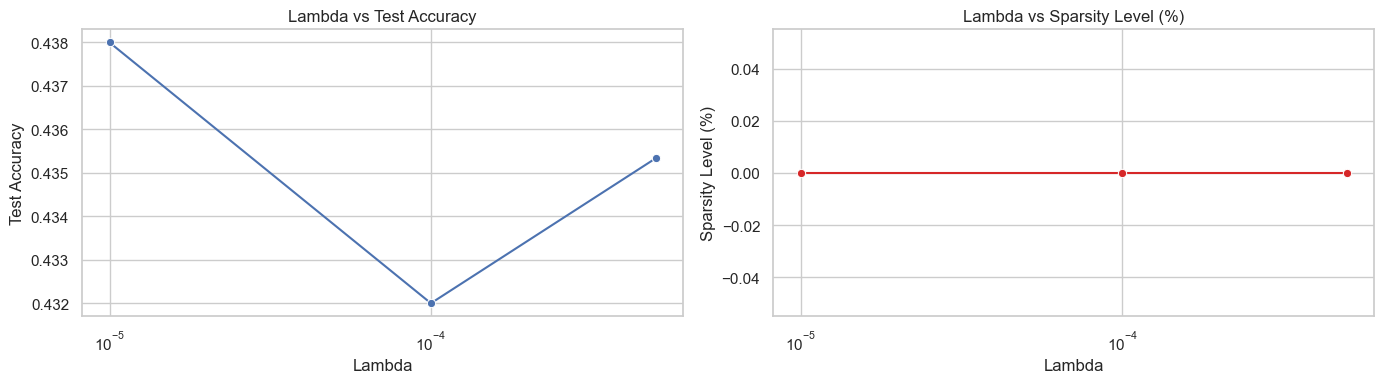

In [14]:
# Trade-off visualization: Accuracy vs Sparsity across lambda
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=summary, x='Lambda', y='Test Accuracy', marker='o', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Lambda vs Test Accuracy')

sns.lineplot(data=summary, x='Lambda', y='Sparsity Level (%)', marker='o', ax=axes[1], color='tab:red')
axes[1].set_xscale('log')
axes[1].set_title('Lambda vs Sparsity Level (%)')

plt.tight_layout()
plt.show()

In [15]:
# Pick best model by weighted F1 (you can switch criterion)
best_idx = summary['Weighted F1'].idxmax()
best_lambda = summary.loc[best_idx, 'Lambda']
best_result = next(r for r in results if r['lambda'] == best_lambda)
best_model = best_result['model']

print('Best Lambda:', best_lambda)
print('Best Test Accuracy:', round(best_result['test_acc'], 4))
print('Best Sparsity (%):', round(best_result['sparsity_%'], 2))

Best Lambda: 1e-05
Best Test Accuracy: 0.438
Best Sparsity (%): 0.0


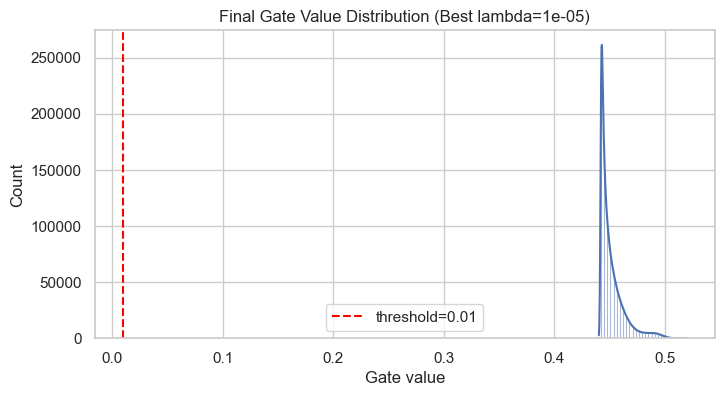

In [16]:
# Distribution of final gate values for best model
gates = best_model.all_gate_values().detach().cpu().numpy()

plt.figure(figsize=(8, 4))
sns.histplot(gates, bins=60, kde=True)
plt.axvline(SPARSITY_THRESHOLD, color='red', linestyle='--', label=f'threshold={SPARSITY_THRESHOLD}')
plt.title(f'Final Gate Value Distribution (Best lambda={best_lambda})')
plt.xlabel('Gate value')
plt.ylabel('Count')
plt.legend()
plt.show()

/Users/diptman/Documents/sayantan/case_study/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Best Model Accuracy: 0.438

Classification Report:


,precision,recall,f1-score,support
airplane,0.625806,0.347670,0.447005,279.000
automobile,0.498442,0.551724,0.523732,290.000
bird,0.317857,0.279874,0.297659,318.000
cat,0.272545,0.448845,0.339152,303.000
deer,0.437158,0.258900,0.325203,309.000
dog,0.507042,0.228571,0.315098,315.000
frog,0.422652,0.523973,0.467890,292.000
horse,0.488372,0.575342,0.528302,292.000
ship,0.486364,0.725424,0.582313,295.000
truck,0.529197,0.472313,0.499139,307.000


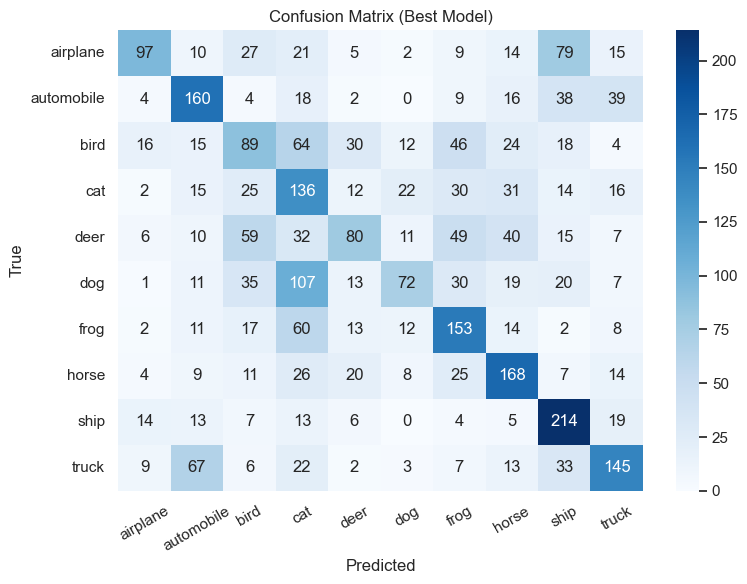

In [17]:
# Detailed evaluation for best model
best_acc, best_report, best_cm, y_true, y_pred = evaluate_model(best_model, test_loader, DEVICE)
print('Best Model Accuracy:', round(best_acc, 4))
print('\nClassification Report:')
display(pd.DataFrame(best_report).transpose())

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/Users/diptman/Documents/sayantan/case_study/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


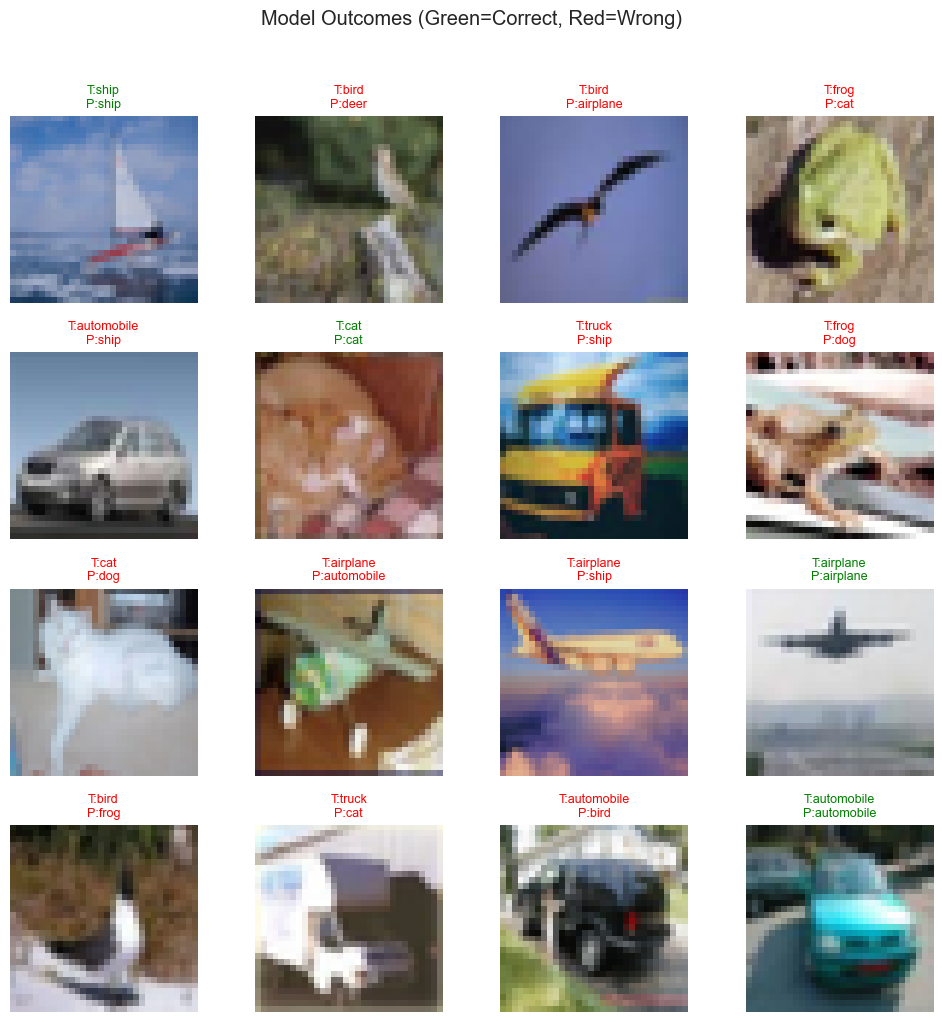

In [18]:
# Model outcomes: show predictions on test images
best_model.eval()
xb, yb = next(iter(test_loader))
xb = xb.to(DEVICE)
with torch.no_grad():
    logits = best_model(xb)
    preds = logits.argmax(dim=1).cpu()

imgs = xb[:16].cpu()
labels = yb[:16]
preds = preds[:16]

imgs = (imgs * torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1) + torch.tensor([0.4914,0.4822,0.4465]).view(1,3,1,1)).clamp(0,1)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].permute(1,2,0).numpy())
    true_name = class_names[labels[i].item()]
    pred_name = class_names[preds[i].item()]
    ok = labels[i].item() == preds[i].item()
    ax.set_title(f'T:{true_name}\nP:{pred_name}', color='green' if ok else 'red', fontsize=9)
    ax.axis('off')
plt.suptitle('Model Outcomes (Green=Correct, Red=Wrong)', y=1.02)
plt.tight_layout()
plt.show()

## Short Report (Markdown)

### Why L1 penalty on sigmoid gates encourages sparsity
Each trainable gate is `sigmoid(gate_score)` and lies in `[0, 1]`. Adding `L1(gates)` to the objective penalizes non-zero gate values. During optimization, this pressure pushes many gates toward values near 0, effectively suppressing their corresponding weights (`weight * gate`). This creates a sparse network where only important connections remain active.

### Required result table
The `summary` dataframe above provides the required columns:
- `Lambda`
- `Test Accuracy`
- `Sparsity Level (%)`

### Notes for final submission
- For quick output, current default is `EPOCHS=2` and `QUICK_MODE=True`.
- For stronger final numbers, set `QUICK_MODE=False` and increase `EPOCHS` (e.g., `15` or `25`).
- Keep the same code and only change config values.